# Eksperyment 5: Wpływ zaburzeń obrazu na jakość opisu

**Przedmiot:** ADOM  
**Metoda:** Show and Tell - automatyczne opisywanie obrazów  
**Data realizacji:** Maj 2025

---

## Cel eksperymentu

Zbadanie odporności (*robustness*) modelu na typowe zniekształcenia obrazu:
rozmycie, szum gaussowski, zmianę kontrastu i rotację.

**Hipoteza:** Wraz ze wzrostem intensywności zaburzenia BLEU-4 powinno maleć.
Rozmycie powinno być najbardziej destrukcyjne - niszczy krawędzie obiektów,
które enkoder ResNet wykrywa jako główne cechy wizualne.

---

## Metodologia

Dla każdego z 9 warunków testowych generujemy opisy dla tych samych N=1000
obrazów ze zbioru testowego i obliczamy BLEU-4.

Każdy obraz jest najpierw normalizowany do 256×256, a dopiero potem nakładane
jest zaburzenie - gwarantuje to spójną siłę zaburzenia niezależnie od
oryginalnego rozmiaru zdjęcia.

| Zaburzenie | Warianty |
|------------|----------|
| Brak | baseline - brak zaburzenia |
| Rozmycie Gaussa | promień r=2 (lekkie), r=5 (silne) |
| Szum Gaussa | σ=20 (lekki), σ=50 (silny) |
| Niski kontrast | 50% kontrastu (lekki), 20% kontrastu (silny) |
| Obrót | 15° (lekki), 45° (silny) |

In [1]:
import sys, os, json, torch, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm

# Seeding for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sys.path.append(os.path.abspath(os.path.join('..')))
from caption import caption_image_beam_search

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORD_MAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
VAL_IMAGES_DIR = '../dataset/val2014'
DATASET_JSON = '../dataset/caption_datasets/dataset_coco.json'

SAMPLE_SIZE = 1000
BEAM_SIZE = 3

with open(WORD_MAP_PATH, 'r') as j: word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

checkpoint = torch.load(MODEL_PATH, map_location=str(DEVICE), weights_only=False)
decoder, encoder = checkpoint['decoder'].to(DEVICE).eval(), checkpoint['encoder'].to(DEVICE).eval()

# Rigorous sampling (Preventing silent file skipping)
with open(DATASET_JSON, 'r') as j:
    all_test_images = [img for img in json.load(j)['images'] if img['split'] == 'test']

valid_images = [img for img in all_test_images if os.path.exists(os.path.join(VAL_IMAGES_DIR, img['filename']))]
sampled_images = random.sample(valid_images, min(SAMPLE_SIZE, len(valid_images)))
references_dict = {img['filename']: [c['tokens'] for c in img['sentences']] for img in sampled_images}

print(f"Rigorous sampling complete: {len(references_dict)} images ready for perturbation testing.")

Rigorous sampling complete: 1000 images ready for perturbation testing.


## Funkcja zaburzeń

Wszystkie zaburzenia aplikowane są po normalizacji obrazu do 256×256.
Dzięki temu parametry (np. `radius=5`) mają identyczny efekt wizualny
niezależnie od oryginalnego rozmiaru zdjęcia.

In [ ]:
def apply_perturbation(image_path, p_type, severity):
    """
    Reads image, NORMALIZES SIZE to 256x256, 
    and applies perturbation with given severity.
    """
    img = Image.open(image_path).convert('RGB')
    
    img = img.resize((256, 256), Image.LANCZOS)
    
    if p_type == "Clean":
        return img
    elif p_type == "Gaussian_Blur":
        return img.filter(ImageFilter.GaussianBlur(radius=severity))
    elif p_type == "Low_Contrast":
        return ImageEnhance.Contrast(img).enhance(severity)
    elif p_type == "Gaussian_Noise":
        img_np = np.array(img).astype(np.float32)
        noise = np.random.normal(0, severity, img_np.shape)
        return Image.fromarray(np.clip(img_np + noise, 0, 255).astype(np.uint8))
    elif p_type == "Rotation":
        return img.rotate(severity, fillcolor=(0, 0, 0))
        
    return img

## Ewaluacja

Dla każdego warunku testowego iterujemy przez wszystkie 1000 obrazów,
aplikujemy zaburzenie i generujemy opis przy `beam_size=3`.
Wyniki zbierane są jako `corpus_bleu` - identycznie jak w pozostałych
eksperymentach.

In [4]:
test_suite = [
    ("Clean",         0,    "Clean (Baseline)"),
    ("Gaussian_Blur", 2,    "Blur (r=2)"),
    ("Gaussian_Blur", 5,    "Blur (r=5)"),
    ("Gaussian_Noise", 20,  "Noise (σ=20)"),
    ("Gaussian_Noise", 50,  "Noise (σ=50)"),
    ("Low_Contrast",  0.5,  "Contrast (50%)"),
    ("Low_Contrast",  0.2,  "Contrast (20%)"),
    ("Rotation",      15,   "Rotate (15°)"),
    ("Rotation",      45,   "Rotate (45°)"),
]

robustness_results = {}

for p_type, severity, label in test_suite:
    actual_refs, actual_hyps = [], []

    for filename, refs in tqdm(references_dict.items(), desc=f"Eval: {label}"):
        img = apply_perturbation(os.path.join(VAL_IMAGES_DIR, filename), p_type, severity)
        seq, _ = caption_image_beam_search(encoder, decoder, img, word_map, BEAM_SIZE)
        hypothesis = [rev_word_map[w] for w in seq
                      if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        actual_refs.append(refs)
        actual_hyps.append(hypothesis)

    robustness_results[label] = corpus_bleu(actual_refs, actual_hyps,
                                            weights=(0.25, 0.25, 0.25, 0.25))

Eval: Rotate (45°): 100%|██████████| 1000/1000 [00:28<00:00, 35.18it/s]


## Wyniki

Tabela BLEU-4 dla każdego warunku testowego oraz wykres słupkowy.

,BLEU4
Clean (Baseline),0.3363
Blur (r=2),0.2567
Blur (r=5),0.0425
Noise (σ=20),0.2843
Noise (σ=50),0.1357
Contrast (50%),0.3188
Contrast (20%),0.2747
Rotate (15°),0.2762
Rotate (45°),0.2021


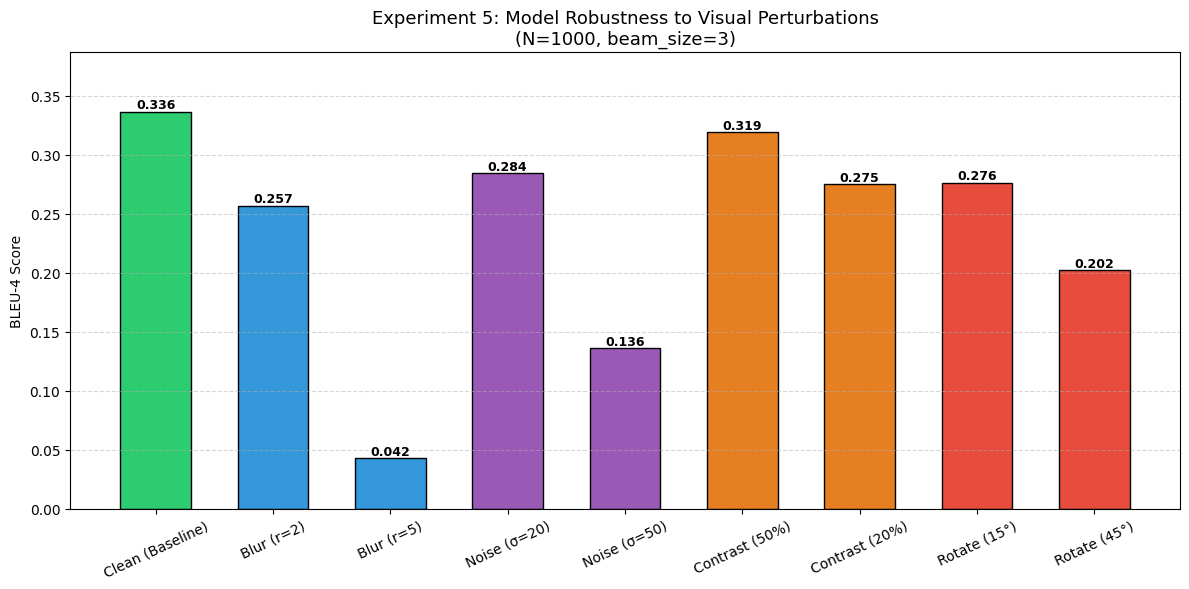

In [5]:
df_rob = pd.DataFrame.from_dict(robustness_results, orient='index', columns=['BLEU4'])
display(df_rob.round(4))

colors = ['#2ecc71'] + ['#3498db']*2 + ['#9b59b6']*2 + ['#e67e22']*2 + ['#e74c3c']*2

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(df_rob.index, df_rob['BLEU4'], color=colors, width=0.6, edgecolor='black')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', fontsize=9, fontweight='bold')

ax.set_title('Experiment 5: Model Robustness to Visual Perturbations\n(N=1000, beam_size=3)', fontsize=13)
ax.set_ylabel('BLEU-4 Score')
ax.set_ylim(0, df_rob['BLEU4'].max() * 1.15)
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Analiza jakościowa

Wizualizacja losowego obrazu po każdym typie silnego zaburzenia
wraz z wygenerowanym opisem - pozwala ocenić jak zaburzenie zmienia
percepcję modelu w konkretnym przypadku.

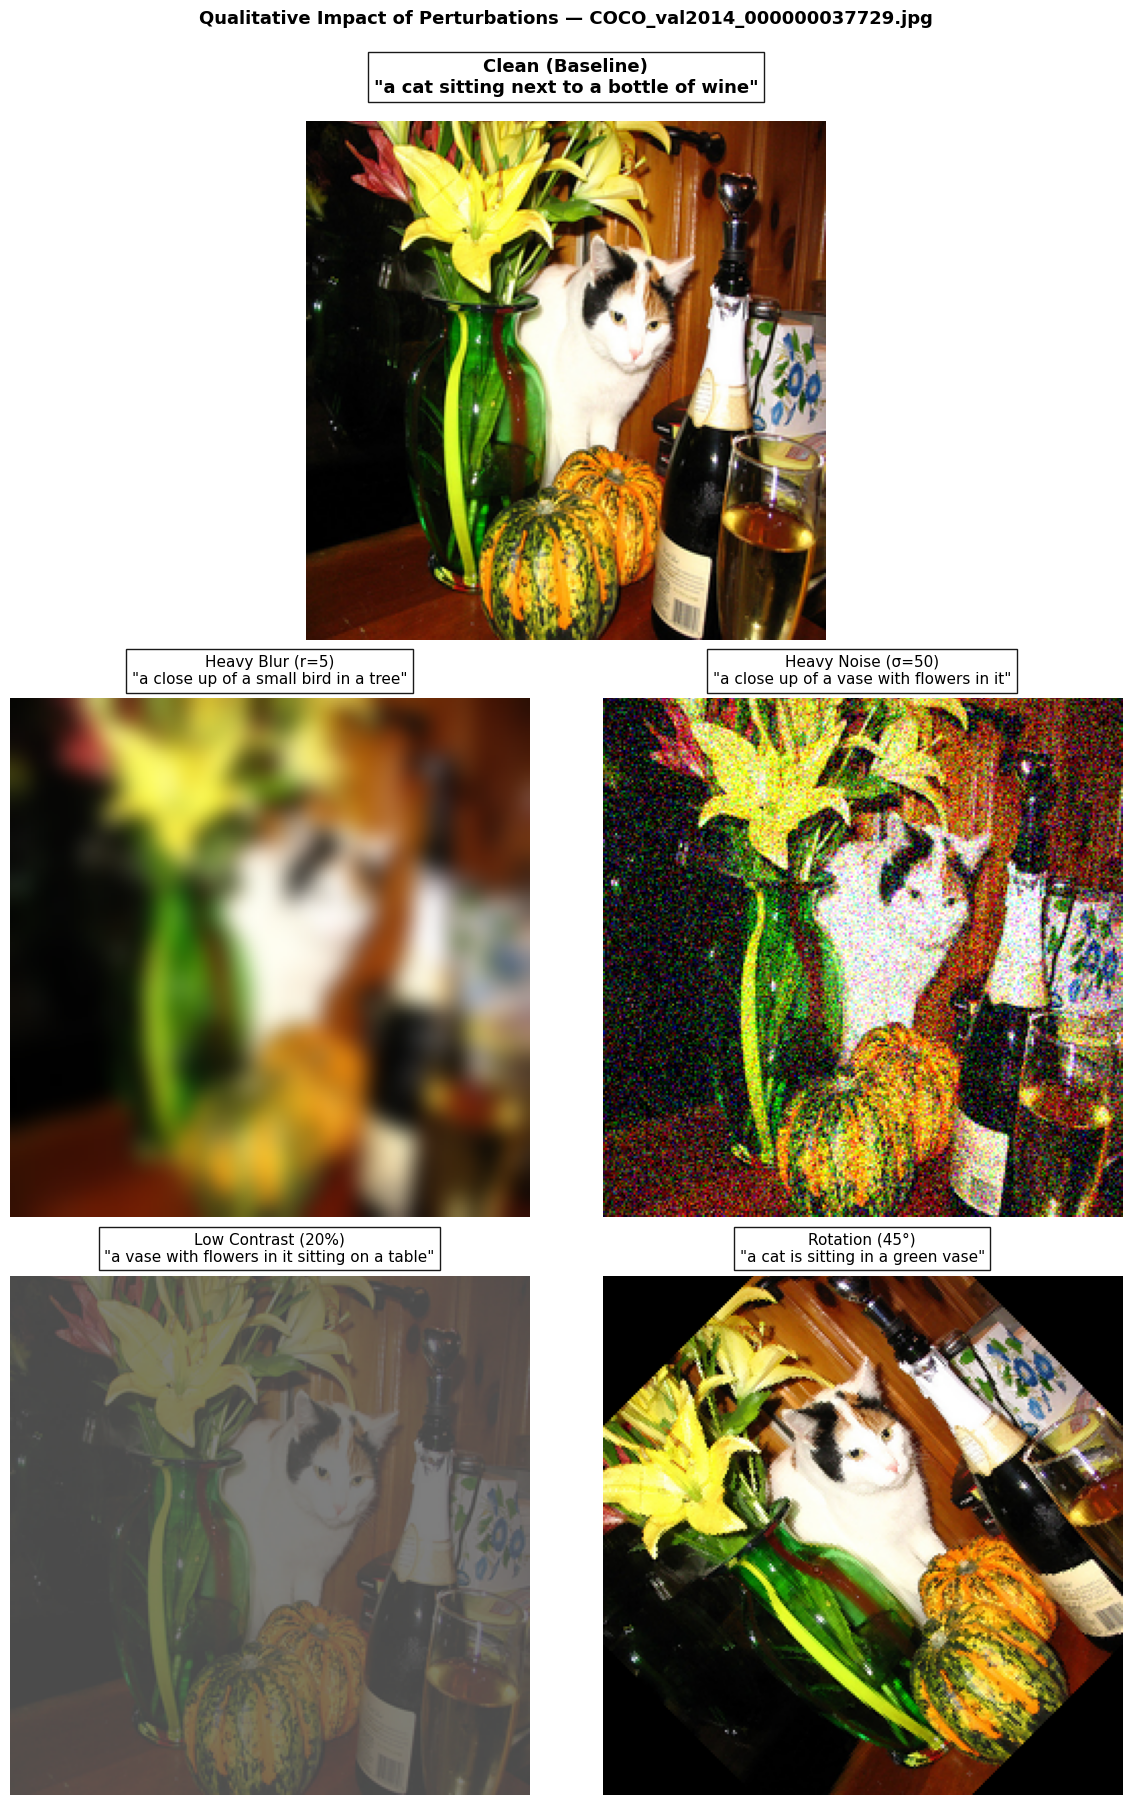

In [ ]:
sample_filename = random.choice(list(references_dict.keys()))
sample_path = os.path.join(VAL_IMAGES_DIR, sample_filename)

demo_suite_perturbed = [
    ("Gaussian_Blur",  5,  "Heavy Blur (r=5)"),
    ("Gaussian_Noise", 50, "Heavy Noise (σ=50)"),
    ("Low_Contrast",   0.2,"Low Contrast (20%)"),
    ("Rotation",       45, "Rotation (45°)"),
]

fig = plt.figure(figsize=(12, 18))

# --- Top: large clean image ---
ax_clean = fig.add_subplot(3, 1, 1)
clean_img = apply_perturbation(sample_path, "Clean", 0)
seq, _ = caption_image_beam_search(encoder, decoder, clean_img, word_map, BEAM_SIZE)
clean_hyp = " ".join([rev_word_map[w] for w in seq
                      if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}])
ax_clean.imshow(clean_img)
ax_clean.axis('off')
ax_clean.set_title(f'Clean (Baseline)\n"{clean_hyp}"', fontsize=13, fontweight='bold',
                   pad=20, bbox=dict(facecolor='white', alpha=0.9))

# --- Bottom: 2x2 grid of perturbations ---
for i, (p_type, severity, label) in enumerate(demo_suite_perturbed):
    ax = fig.add_subplot(3, 2, i + 3)
    img = apply_perturbation(sample_path, p_type, severity)
    seq, _ = caption_image_beam_search(encoder, decoder, img, word_map, BEAM_SIZE)
    hyp = " ".join([rev_word_map[w] for w in seq
                    if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{label}\n"{hyp}"', fontsize=11, pad=10,
                 bbox=dict(facecolor='white', alpha=0.9))

fig.suptitle(f'Qualitative Impact of Perturbations - {sample_filename}',
             fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## Wnioski:

**Obserwacje:**
- **Rozmycie (r=5)** jest zdecydowanie najbardziej destrukcyjnym zaburzeniem -
  BLEU-4 spada o 87% (z 0.336 do 0.042). ResNet opiera się na gradientach
  krawędzi, które silny blur całkowicie niszczy. Model przestaje dobrze
  identyfikować obiekty i sceny.

- **Szum gaussowski (σ=50)** powoduje 60% spadek BLEU-4. Jest mniej destrukcyjny
  niż silne rozmycie, bo szum zaburza wartości pojedynczych pikseli,
  ale zachowuje krawędzie obiektów które ResNet traktuje jako główne cechy.

- **Zmiana kontrastu** jest zaskakująco mało destrukcyjna - przy 50% kontrastu
  model traci zaledwie 5% jakości. Nawet przy 20% kontrastu (obraz prawie szary)
  spadek wynosi tylko 18%, co sugeruje że ResNet jest naturalnie odporny
  na globalne zmiany jasności.

- **Rotacja 45°** powoduje 40% spadek - model był trenowany wyłącznie na obrazach
  w standardowej orientacji i nie jest odporny na obroty geometryczne.
  Lekka rotacja 15° daje podobny spadek jak zmiana kontrastu do 20% (-18%).


**Ranking destrukcyjności zaburzeń:**

Blur >> Noise > Rotation > Contrast